<a href="https://colab.research.google.com/github/RafaelCardoso140701/MBA---Mackenzie/blob/main/Tarefa_1_aula_LINGUAGENS_DE_PROGPARA_DADOS_E_ANALYTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CÉLULA 1: Importações ───────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (13, 5)
print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [3]:
# ── CÉLULA 2: Carregamento via GitHub ───────────────────────────
BASE_URL = (
    "https://raw.githubusercontent.com/"
    "DeepFluxion/Mack_2026_Language_Analitycs/main/data/"
)
# Carrega as tabelas necessárias para este tutorial
df_orders    = pd.read_csv(BASE_URL + "olist_orders_dataset.csv")
df_customers = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
df_reviews   = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv")
df_items     = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv")
df_products  = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
df_translate = pd.read_csv(BASE_URL + "product_category_name_translation.csv")

# Confirma o carregamento de cada arquivo
tabelas = {"orders":df_orders, "customers":df_customers,
           "reviews":df_reviews, "items":df_items,
           "products":df_products, "translation":df_translate}

print("{:<15} {:>10} {:>8}".format("Tabela","Linhas","Colunas"))
print("=" * 36)
for n,df in tabelas.items(): print("{:<15} {:>10,} {:>8}".format(n,df.shape[0],df.shape[1]))



Tabela              Linhas  Colunas
orders              99,441        8
customers           99,441        5
reviews             99,224        7
items              112,650        7
products            32,951        9
translation             71        2


In [4]:
# ── CÉLULA 3: Inspecionar colunas de data em df_orders ──────────
print("Colunas e tipos em df_orders:")
print(df_orders.dtypes)

# Mostra as 3 primeiras linhas das colunas de data
cols_data = ["order_purchase_timestamp",
             "order_estimated_delivery_date",
             "order_delivered_customer_date"]

print("\nExemplos de valores:")
print(df_orders[cols_data].head(3).to_string())


Colunas e tipos em df_orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Exemplos de valores:
  order_purchase_timestamp order_estimated_delivery_date order_delivered_customer_date
0      2017-10-02 10:56:33           2017-10-18 00:00:00           2017-10-10 21:25:13
1      2018-07-24 20:41:37           2018-08-13 00:00:00           2018-08-07 15:27:45
2      2018-08-08 08:38:49           2018-09-04 00:00:00           2018-08-17 18:06:29


## Etapa 1 — Cálculo do Lead Time de Entrega

### (a) O que é Lead Time?

**Lead time** é o tempo total decorrido entre a compra de um pedido pelo cliente e a sua efetiva entrega. É uma métrica fundamental de logística e experiência do cliente: quanto menor e mais previsível o lead time, melhor a percepção de qualidade do serviço.

### (b) As três métricas calculadas

1. **lead_time_real**: quantos dias o pedido *de fato* levou para ser entregue (da compra até a entrega real).
2. **lead_time_estimado**: quantos dias a Olist **prometeu** ao cliente no momento da compra (da compra até a data estimada de entrega).
3. **diferenca_prazo**: a diferença entre o tempo real e o tempo estimado. Indica se o pedido chegou **antes, no prazo ou depois** do que foi prometido.

### (c) Por que a diferença de prazo é a métrica mais relevante?

Um lead time real de 10 dias pode ser ótimo ou péssimo — depende do que foi prometido. Se a estimativa era de 5 dias, o cliente está **atrasado em 5 dias** (experiência ruim). Se a estimativa era de 15 dias, o pedido chegou **5 dias antes** (experiência ótima, supera expectativa).

Ou seja, **o que importa para a satisfação do cliente não é o tempo absoluto, e sim o cumprimento da promessa feita no momento da compra**. A `diferenca_prazo` captura exatamente esse gap entre expectativa e realidade, sendo o indicador mais direto de performance logística e de risco de insatisfação/reclamação.

### Fórmulas

| Métrica              | Fórmula                                                          | Interpretação                          |
|-----------------------|-------------------------------------------------------------------|------------------------------------------|
| `lead_time_real`       | `order_delivered_customer_date - order_purchase_timestamp`        | Dias reais até a entrega                |
| `lead_time_estimado`   | `order_estimated_delivery_date - order_purchase_timestamp`        | Dias prometidos até a entrega           |
| `diferenca_prazo`      | `lead_time_real - lead_time_estimado`                              | <= 0: no prazo / > 0: atrasado          |

In [5]:
# ============================================================
# ETAPA 1 — CÁLCULO DO LEAD TIME DE ENTREGA
# ============================================================

import pandas as pd

# --------------------------------------------------------------
# a) Cópia de df_orders filtrada apenas para pedidos "delivered"
# --------------------------------------------------------------
df_lead = df_orders[df_orders["order_status"] == "delivered"].copy()

# --------------------------------------------------------------
# b) Remove linhas com datas nulas (entrega ou estimativa ausente)
#    Guardamos o total antes para reportar quantos foram descartados
# --------------------------------------------------------------
total_antes = len(df_lead)

df_lead = df_lead.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
)

total_descartados = total_antes - len(df_lead)

# --------------------------------------------------------------
# c) Converte as três colunas de data de texto para datetime
# --------------------------------------------------------------
colunas_data = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in colunas_data:
    df_lead[col] = pd.to_datetime(df_lead[col])

# --------------------------------------------------------------
# d) Calcula as três métricas de lead time (em dias inteiros)
# --------------------------------------------------------------
df_lead["lead_time_real"] = (
    df_lead["order_delivered_customer_date"] - df_lead["order_purchase_timestamp"]
).dt.days

df_lead["lead_time_estimado"] = (
    df_lead["order_estimated_delivery_date"] - df_lead["order_purchase_timestamp"]
).dt.days

df_lead["diferenca_prazo"] = df_lead["lead_time_real"] - df_lead["lead_time_estimado"]

# --------------------------------------------------------------
# e) Cria a coluna categórica de status de entrega
# --------------------------------------------------------------
df_lead["status_entrega"] = df_lead["diferenca_prazo"].apply(
    lambda x: "No Prazo" if x <= 0 else "Atrasado"
)

# --------------------------------------------------------------
# f) Merge com df_customers para trazer o estado do cliente
# --------------------------------------------------------------
df_lead = df_lead.merge(
    df_customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left",
)

# --------------------------------------------------------------
# g) Seleciona e organiza as colunas finais de df_lead
# --------------------------------------------------------------
df_lead = df_lead[
    [
        "order_id",
        "order_purchase_timestamp",
        "lead_time_real",
        "lead_time_estimado",
        "diferenca_prazo",
        "status_entrega",
        "customer_state",
    ]
]

# --------------------------------------------------------------
# h) Relatório formatado com estatísticas descritivas
# --------------------------------------------------------------
total_pedidos = len(df_lead)

media_real = df_lead["lead_time_real"].mean()
mediana_real = df_lead["lead_time_real"].median()
min_real = df_lead["lead_time_real"].min()
max_real = df_lead["lead_time_real"].max()

media_estimado = df_lead["lead_time_estimado"].mean()
mediana_estimado = df_lead["lead_time_estimado"].median()

pct_no_prazo = (df_lead["status_entrega"] == "No Prazo").mean() * 100
pct_atrasado = (df_lead["status_entrega"] == "Atrasado").mean() * 100

print("=" * 55)
print("RELATÓRIO — LEAD TIME DE ENTREGA (pedidos 'delivered')")
print("=" * 55)
print(f"Total de pedidos analisados: {total_pedidos}")
print(f"Pedidos descartados (datas nulas): {total_descartados}")
print("-" * 55)
print("Lead Time REAL (dias):")
print(f"  Média:   {media_real:.1f}")
print(f"  Mediana: {mediana_real:.1f}")
print(f"  Mínimo:  {min_real:.1f}")
print(f"  Máximo:  {max_real:.1f}")
print("-" * 55)
print("Lead Time ESTIMADO (dias):")
print(f"  Média:   {media_estimado:.1f}")
print(f"  Mediana: {mediana_estimado:.1f}")
print("-" * 55)
print("Status de Entrega:")
print(f"  No Prazo: {pct_no_prazo:.1f}%")
print(f"  Atrasado: {pct_atrasado:.1f}%")
print("=" * 55)

df_lead.head()

RELATÓRIO — LEAD TIME DE ENTREGA (pedidos 'delivered')
Total de pedidos analisados: 96470
Pedidos descartados (datas nulas): 8
-------------------------------------------------------
Lead Time REAL (dias):
  Média:   12.1
  Mediana: 10.0
  Mínimo:  0.0
  Máximo:  209.0
-------------------------------------------------------
Lead Time ESTIMADO (dias):
  Média:   23.4
  Mediana: 23.0
-------------------------------------------------------
Status de Entrega:
  No Prazo: 92.4%
  Atrasado: 7.6%


,order_id,order_purchase_timestamp,lead_time_real,lead_time_estimado,diferenca_prazo,status_entrega,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,8,15,-7,No Prazo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,13,19,-6,No Prazo,BA
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,9,26,-17,No Prazo,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,13,26,-13,No Prazo,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2,12,-10,No Prazo,SP


## Distribuição do Lead Time

Nesta etapa vamos visualizar como o **lead time de entrega** se comporta na prática, olhando para sua distribuição estatística e para a relação com o prazo prometido ao cliente.

Usamos **histograma e boxplot juntos** porque eles respondem perguntas complementares:

- O **histograma** mostra a *forma* da distribuição — onde estão concentrados os pedidos, se há assimetria (cauda longa de entregas muito demoradas) e onde ficam média e mediana.
- O **boxplot** resume a distribuição em poucos números — mediana, quartis e outliers — facilitando identificar visualmente o quanto os valores extremos (entregas anormalmente lentas) distorcem a média.

Olhar só o histograma pode escorregar a interpretação por causa de outliers extremos (entregas de 100+ dias); olhar só o boxplot esconde a forma geral (ex: bimodalidade). Juntos, dão uma visão completa do comportamento logístico.

Também analisamos a **diferença em relação ao prazo** (atraso vs. adiantamento) e o **status de entrega agregado**, que traduzem a métrica em termos de impacto direto na experiência do cliente.

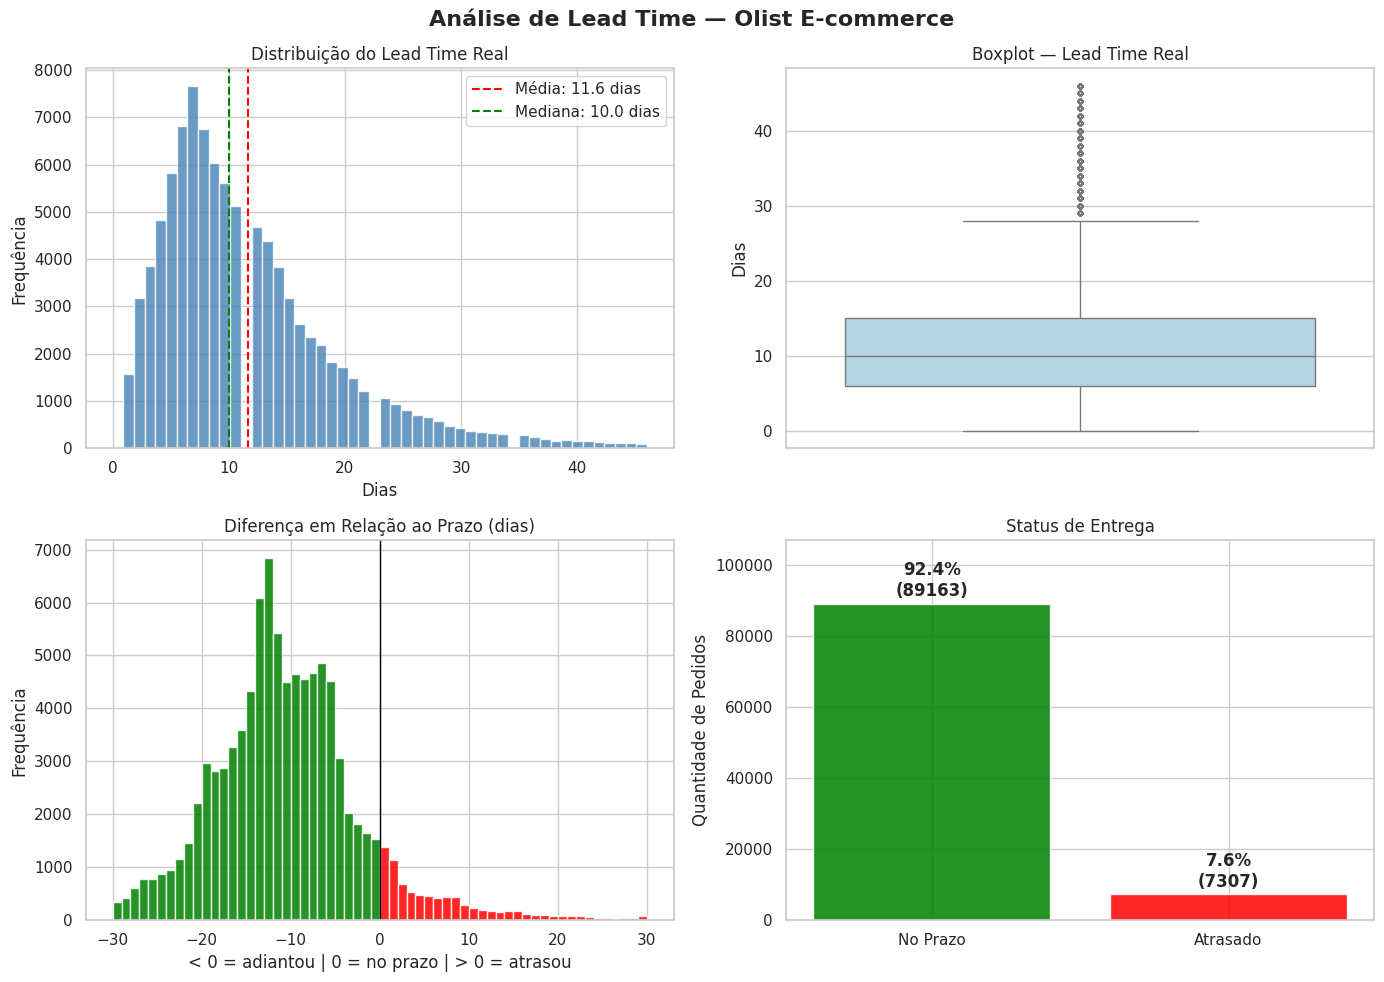

In [6]:
# ============================================================
# VISUALIZAÇÃO — DISTRIBUIÇÃO DO LEAD TIME
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cria figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10), tight_layout=True)

# ------------------------------------------------------------
# [0,0] Histograma do lead_time_real (até percentil 99)
# ------------------------------------------------------------
p99_real = df_lead["lead_time_real"].quantile(0.99)
dados_real = df_lead.loc[df_lead["lead_time_real"] <= p99_real, "lead_time_real"]

media_real = dados_real.mean()
mediana_real = dados_real.median()

ax = axes[0, 0]
ax.hist(dados_real, bins=50, color="steelblue", alpha=0.8)
ax.axvline(media_real, color="red", linestyle="--",
           label=f"Média: {media_real:.1f} dias")
ax.axvline(mediana_real, color="green", linestyle="--",
           label=f"Mediana: {mediana_real:.1f} dias")
ax.set_title("Distribuição do Lead Time Real")
ax.set_xlabel("Dias")
ax.set_ylabel("Frequência")
ax.legend()

# ------------------------------------------------------------
# [0,1] Boxplot do lead_time_real (até percentil 99)
# ------------------------------------------------------------
ax = axes[0, 1]
sns.boxplot(
    y=dados_real,
    ax=ax,
    color="lightblue",
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
)
ax.set_title("Boxplot — Lead Time Real")
ax.set_ylabel("Dias")

# ------------------------------------------------------------
# [1,0] Histograma da diferenca_prazo (entre -30 e +30 dias)
#   Barras negativas (adiantado) em verde, positivas (atrasado) em vermelho
# ------------------------------------------------------------
ax = axes[1, 0]
dados_diff = df_lead.loc[
    (df_lead["diferenca_prazo"] >= -30) & (df_lead["diferenca_prazo"] <= 30),
    "diferenca_prazo",
]

bins = np.arange(-30, 31, 1)  # bins de 1 dia
counts, bin_edges, patches = ax.hist(dados_diff, bins=bins, alpha=0.85)

# Colore cada barra conforme o lado do zero
for patch, edge in zip(patches, bin_edges[:-1]):
    patch.set_facecolor("green" if edge < 0 else "red")

ax.axvline(0, color="black", linestyle="-", linewidth=1)
ax.set_title("Diferença em Relação ao Prazo (dias)")
ax.set_xlabel("< 0 = adiantou | 0 = no prazo | > 0 = atrasou")
ax.set_ylabel("Frequência")

# ------------------------------------------------------------
# [1,1] Barplot do status_entrega com percentual e contagem
# ------------------------------------------------------------
ax = axes[1, 1]
contagem = df_lead["status_entrega"].value_counts()
total = contagem.sum()

cores = {"No Prazo": "green", "Atrasado": "red"}
ordem = ["No Prazo", "Atrasado"]
valores = [contagem.get(cat, 0) for cat in ordem]
cores_barras = [cores[cat] for cat in ordem]

barras = ax.bar(ordem, valores, color=cores_barras, alpha=0.85)

# Anota percentual e contagem acima de cada barra
for barra, valor in zip(barras, valores):
    pct = valor / total * 100
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + total * 0.01,
        f"{pct:.1f}%\n({valor})",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title("Status de Entrega")
ax.set_ylabel("Quantidade de Pedidos")
ax.set_ylim(0, max(valores) * 1.2)

# ------------------------------------------------------------
# Título geral e salvamento
# ------------------------------------------------------------
fig.suptitle("Análise de Lead Time — Olist E-commerce", fontsize=16, fontweight="bold")
plt.savefig("lead_time_distribuicao.png", dpi=120, bbox_inches="tight")
plt.show()

## Lead Time por Estado — A Disparidade Regional

A média nacional de lead time é útil como referência geral, mas ela **esconde disparidades regionais** importantes: um país com a dimensão continental do Brasil tem realidades logísticas muito diferentes entre regiões — distância dos centros de distribuição, infraestrutura de transporte, malha viária — que afetam diretamente o tempo de entrega.

Um estado com lead time médio próximo da média nacional pode mascarar, na verdade, dois extremos: capitais bem servidas e regiões remotas com entregas muito mais lentas dentro do mesmo estado.

Nesta etapa, vamos **identificar os estados mais críticos** — aqueles com lead time médio mais alto e menor percentual de entregas no prazo — para direcionar ações de melhoria logística onde elas têm maior impacto.

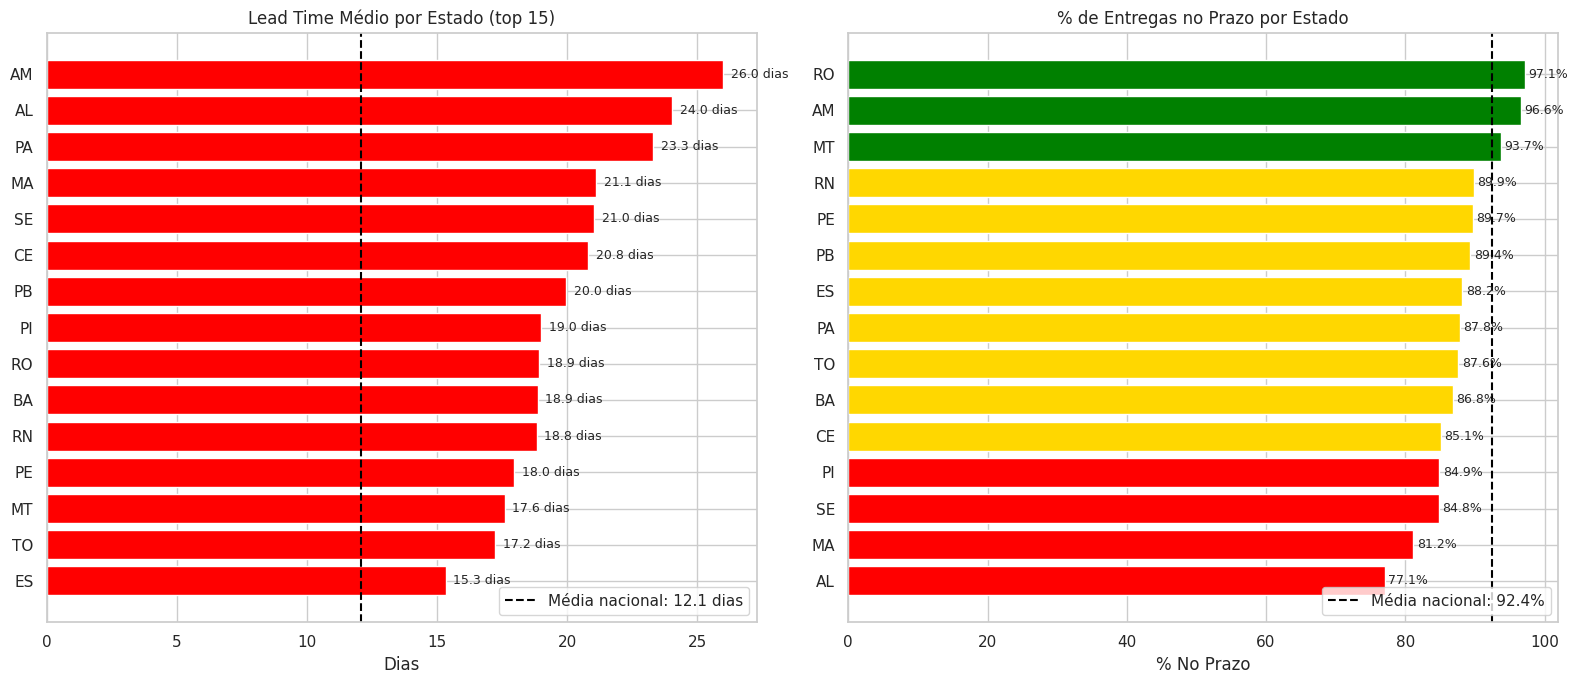

RELATÓRIO — LEAD TIME POR ESTADO

Média nacional de lead time: 12.1 dias
Média nacional de entregas no prazo: 92.4%

--- TOP 5 ESTADOS COM MAIOR LEAD TIME MÉDIO (mais críticos) ---
  AM: 26.0 dias (145 pedidos, 96.6% no prazo)
  AL: 24.0 dias (397 pedidos, 77.1% no prazo)
  PA: 23.3 dias (946 pedidos, 87.8% no prazo)
  MA: 21.1 dias (717 pedidos, 81.2% no prazo)
  SE: 21.0 dias (335 pedidos, 84.8% no prazo)

--- TOP 5 ESTADOS COM MENOR LEAD TIME MÉDIO (mais eficientes) ---
  SP: 8.3 dias (40494 pedidos, 94.7% no prazo)
  PR: 11.5 dias (4923 pedidos, 95.4% no prazo)
  MG: 11.5 dias (11354 pedidos, 94.8% no prazo)
  DF: 12.5 dias (2080 pedidos, 93.4% no prazo)
  SC: 14.5 dias (3546 pedidos, 90.8% no prazo)


In [7]:
# ============================================================
# LEAD TIME POR ESTADO — ANÁLISE DE DISPARIDADE REGIONAL
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------
# a) Agrupa por customer_state e calcula as métricas agregadas
#    Mantém apenas estados com >= 100 pedidos (significância estatística)
# --------------------------------------------------------------
df_estado = df_lead.groupby("customer_state").agg(
    lead_medio=("lead_time_real", "mean"),
    lead_mediana=("lead_time_real", "median"),
    total_pedidos=("lead_time_real", "count"),
    pct_no_prazo=("status_entrega", lambda x: (x == "No Prazo").sum() / len(x) * 100),
).reset_index()

df_estado = df_estado[df_estado["total_pedidos"] >= 100]

# --------------------------------------------------------------
# b) Ordena por lead_medio decrescente (mais lento primeiro)
# --------------------------------------------------------------
df_estado = df_estado.sort_values("lead_medio", ascending=False)

# Médias nacionais de referência (calculadas sobre todo o df_lead, não só os filtrados)
media_nacional_lead = df_lead["lead_time_real"].mean()
media_nacional_pct = (df_lead["status_entrega"] == "No Prazo").mean() * 100

# Seleciona top 15 estados (mais lentos) para os gráficos
top15 = df_estado.head(15).copy()

# --------------------------------------------------------------
# c) Figura com 2 subplots lado a lado
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ----------------------------------------------------------
# Subplot esquerdo: Lead time médio por estado
#   Ordenado do mais lento (topo) ao mais rápido (base)
# ----------------------------------------------------------
ax = axes[0]

# top15 já está ordenado decrescente; invertemos para o mais lento ficar no topo do gráfico
plot_data = top15.sort_values("lead_medio", ascending=True)

cores_lead = [
    "red" if v > media_nacional_lead else "steelblue"
    for v in plot_data["lead_medio"]
]

barras = ax.barh(plot_data["customer_state"], plot_data["lead_medio"], color=cores_lead)

# Linha vertical tracejada na média nacional
ax.axvline(media_nacional_lead, color="black", linestyle="--", linewidth=1.5,
           label=f"Média nacional: {media_nacional_lead:.1f} dias")

# Valor numérico no final de cada barra
for barra, valor in zip(barras, plot_data["lead_medio"]):
    ax.text(
        valor + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f} dias",
        va="center",
        fontsize=9,
    )

ax.set_title("Lead Time Médio por Estado (top 15)")
ax.set_xlabel("Dias")
ax.legend(loc="lower right")

# ----------------------------------------------------------
# Subplot direito: % de entregas no prazo por estado
#   Mesmos 15 estados, ordenados pelo pior % (topo) ao melhor (base)
# ----------------------------------------------------------
ax = axes[1]

plot_data_pct = top15.sort_values("pct_no_prazo", ascending=False)
# Invertendo para o pior (menor %) ficar no topo
plot_data_pct = plot_data_pct.sort_values("pct_no_prazo", ascending=True)

def cor_pct(p):
    if p < 85:
        return "red"
    elif p <= 92:
        return "gold"
    else:
        return "green"

cores_pct = [cor_pct(v) for v in plot_data_pct["pct_no_prazo"]]

barras2 = ax.barh(plot_data_pct["customer_state"], plot_data_pct["pct_no_prazo"], color=cores_pct)

# Linha vertical na média nacional (%)
ax.axvline(media_nacional_pct, color="black", linestyle="--", linewidth=1.5,
           label=f"Média nacional: {media_nacional_pct:.1f}%")

for barra, valor in zip(barras2, plot_data_pct["pct_no_prazo"]):
    ax.text(
        valor + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        va="center",
        fontsize=9,
    )

ax.set_title("% de Entregas no Prazo por Estado")
ax.set_xlabel("% No Prazo")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# d) Relatório textual — top 5 piores, top 5 melhores e média nacional
# --------------------------------------------------------------
print("=" * 60)
print("RELATÓRIO — LEAD TIME POR ESTADO")
print("=" * 60)

print(f"\nMédia nacional de lead time: {media_nacional_lead:.1f} dias")
print(f"Média nacional de entregas no prazo: {media_nacional_pct:.1f}%")

print("\n--- TOP 5 ESTADOS COM MAIOR LEAD TIME MÉDIO (mais críticos) ---")
top5_piores = df_estado.head(5)
for _, row in top5_piores.iterrows():
    print(
        f"  {row['customer_state']}: {row['lead_medio']:.1f} dias "
        f"({int(row['total_pedidos'])} pedidos, {row['pct_no_prazo']:.1f}% no prazo)"
    )

print("\n--- TOP 5 ESTADOS COM MENOR LEAD TIME MÉDIO (mais eficientes) ---")
top5_melhores = df_estado.sort_values("lead_medio", ascending=True).head(5)
for _, row in top5_melhores.iterrows():
    print(
        f"  {row['customer_state']}: {row['lead_medio']:.1f} dias "
        f"({int(row['total_pedidos'])} pedidos, {row['pct_no_prazo']:.1f}% no prazo)"
    )

print("=" * 60)

## Análise Temporal — Black Friday 2017

A análise temporal nos permite observar como o lead time de entrega evoluiu mês a mês, em vez de olhar apenas uma média estática. Isso é especialmente importante para identificar **eventos sazonais que podem ter causado anomalias operacionais**.

Novembro de 2017 é um mês de interesse particular porque coincide com a **Black Friday** — um evento de pico de demanda que costuma sobrecarregar centros de distribuição, transportadoras e estoques. Picos de volume sem capacidade logística proporcional tendem a gerar atrasos em cascata.

Nesta etapa, vamos verificar se novembro/2017 realmente se destaca como um **ponto de anomalia** em relação ao restante de 2017-2018, olhando simultaneamente para: lead time médio, percentual de entregas no prazo e volume de pedidos — as três dimensões que, juntas, contam a história completa de uma possível sobrecarga operacional.

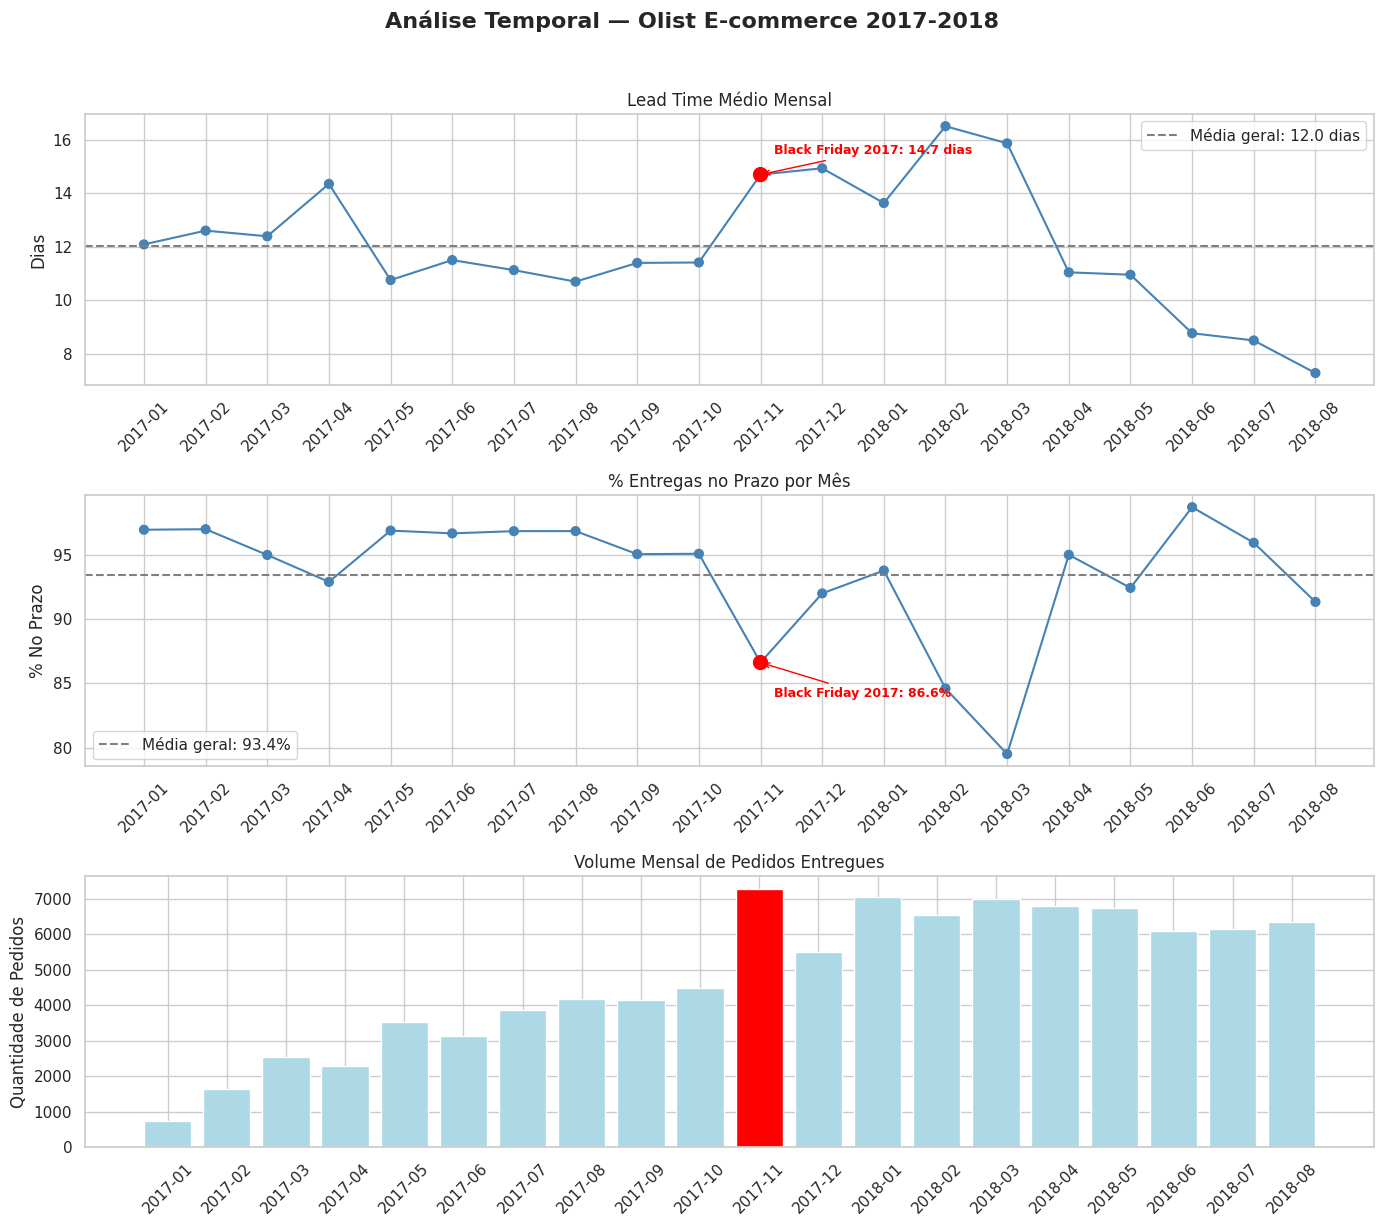

Novembro 2017 vs Média Geral:
  Lead time médio: 14.7 dias vs 12.0 dias
  % no prazo: 86.6% vs 93.4%
  Volume: 7288 pedidos vs 4810.1 pedidos (média mensal)


In [8]:
# ============================================================
# ANÁLISE TEMPORAL — BLACK FRIDAY 2017
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------
# a) Filtra apenas pedidos de 2017 e 2018 (exclui 2016)
# --------------------------------------------------------------
df_temporal = df_lead[
    df_lead["order_purchase_timestamp"].dt.year.isin([2017, 2018])
].copy()

# --------------------------------------------------------------
# b) Cria coluna ano_mes como Period mensal
# --------------------------------------------------------------
df_temporal["ano_mes"] = df_temporal["order_purchase_timestamp"].dt.to_period("M")

# --------------------------------------------------------------
# c) Agrega por mês: lead médio, % no prazo e volume
# --------------------------------------------------------------
df_mensal = df_temporal.groupby("ano_mes").agg(
    lead_medio=("lead_time_real", "mean"),
    pct_no_prazo=("status_entrega", lambda x: (x == "No Prazo").sum() / len(x) * 100),
    volume=("lead_time_real", "count"),
).reset_index()

# --------------------------------------------------------------
# d) Marca o mês da Black Friday (novembro/2017)
# --------------------------------------------------------------
df_mensal["is_bfriday"] = df_mensal["ano_mes"] == pd.Period("2017-11", freq="M")

# Médias gerais de referência (sobre todo o período 2017-2018)
media_geral_lead = df_mensal["lead_medio"].mean()
media_geral_pct = df_mensal["pct_no_prazo"].mean()
media_geral_volume = df_mensal["volume"].mean()

# Eixo X como string para plotagem
df_mensal["ano_mes_str"] = df_mensal["ano_mes"].astype(str)

# Valores do mês da Black Friday
linha_bf = df_mensal[df_mensal["is_bfriday"]].iloc[0]

# --------------------------------------------------------------
# e) Figura com 3 subplots empilhados
# --------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ------------------------------------------------------------
# Subplot 1: Lead time médio mensal
# ------------------------------------------------------------
ax = axes[0]

cores1 = ["red" if bf else "steelblue" for bf in df_mensal["is_bfriday"]]
tamanhos1 = [100 if bf else 40 for bf in df_mensal["is_bfriday"]]

ax.plot(df_mensal["ano_mes_str"], df_mensal["lead_medio"], color="steelblue", linewidth=1.5, zorder=1)
ax.scatter(df_mensal["ano_mes_str"], df_mensal["lead_medio"], c=cores1, s=tamanhos1, zorder=2)

ax.axhline(media_geral_lead, color="gray", linestyle="--",
           label=f"Média geral: {media_geral_lead:.1f} dias")

# Anotação no ponto de novembro/2017
ax.annotate(
    f"Black Friday 2017: {linha_bf['lead_medio']:.1f} dias",
    xy=(str(linha_bf["ano_mes"]), linha_bf["lead_medio"]),
    xytext=(10, 15),
    textcoords="offset points",
    fontsize=9,
    fontweight="bold",
    color="red",
    arrowprops=dict(arrowstyle="->", color="red"),
)

ax.set_title("Lead Time Médio Mensal")
ax.set_ylabel("Dias")
ax.tick_params(axis="x", rotation=45)
ax.legend()

# ------------------------------------------------------------
# Subplot 2: % de entregas no prazo por mês
# ------------------------------------------------------------
ax = axes[1]

cores2 = ["red" if bf else "steelblue" for bf in df_mensal["is_bfriday"]]
tamanhos2 = [100 if bf else 40 for bf in df_mensal["is_bfriday"]]

ax.plot(df_mensal["ano_mes_str"], df_mensal["pct_no_prazo"], color="steelblue", linewidth=1.5, zorder=1)
ax.scatter(df_mensal["ano_mes_str"], df_mensal["pct_no_prazo"], c=cores2, s=tamanhos2, zorder=2)

ax.axhline(media_geral_pct, color="gray", linestyle="--",
           label=f"Média geral: {media_geral_pct:.1f}%")

ax.annotate(
    f"Black Friday 2017: {linha_bf['pct_no_prazo']:.1f}%",
    xy=(str(linha_bf["ano_mes"]), linha_bf["pct_no_prazo"]),
    xytext=(10, -25),
    textcoords="offset points",
    fontsize=9,
    fontweight="bold",
    color="red",
    arrowprops=dict(arrowstyle="->", color="red"),
)

ax.set_title("% Entregas no Prazo por Mês")
ax.set_ylabel("% No Prazo")
ax.tick_params(axis="x", rotation=45)
ax.legend()

# ------------------------------------------------------------
# Subplot 3: Volume mensal de pedidos entregues
# ------------------------------------------------------------
ax = axes[2]

cores3 = ["red" if bf else "lightblue" for bf in df_mensal["is_bfriday"]]

ax.bar(df_mensal["ano_mes_str"], df_mensal["volume"], color=cores3)
ax.set_title("Volume Mensal de Pedidos Entregues")
ax.set_ylabel("Quantidade de Pedidos")
ax.tick_params(axis="x", rotation=45)

# --------------------------------------------------------------
# Título geral e ajuste de layout
# --------------------------------------------------------------
fig.suptitle("Análise Temporal — Olist E-commerce 2017-2018", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# f) Relatório comparativo: Novembro 2017 vs Média Geral
# --------------------------------------------------------------
print("=" * 60)
print("Novembro 2017 vs Média Geral:")
print("=" * 60)
print(f"  Lead time médio: {linha_bf['lead_medio']:.1f} dias vs {media_geral_lead:.1f} dias")
print(f"  % no prazo: {linha_bf['pct_no_prazo']:.1f}% vs {media_geral_pct:.1f}%")
print(f"  Volume: {int(linha_bf['volume'])} pedidos vs {media_geral_volume:.1f} pedidos (média mensal)")
print("=" * 60)

## Lead Time por Categoria de Produto

Diferentes categorias de produto têm características logísticas distintas: tamanho, peso, fragilidade, necessidade de embalagem especial e até a origem dos fornecedores variam bastante de uma categoria para outra. Isso pode gerar diferenças relevantes no tempo de entrega.

Nesta etapa, vamos cruzar os dados de lead time com a categoria do produto (traduzida para o inglês) para identificar **quais categorias apresentam maior tempo médio de entrega e menor percentual de cumprimento de prazo**, ajudando a direcionar ações específicas por tipo de produto.

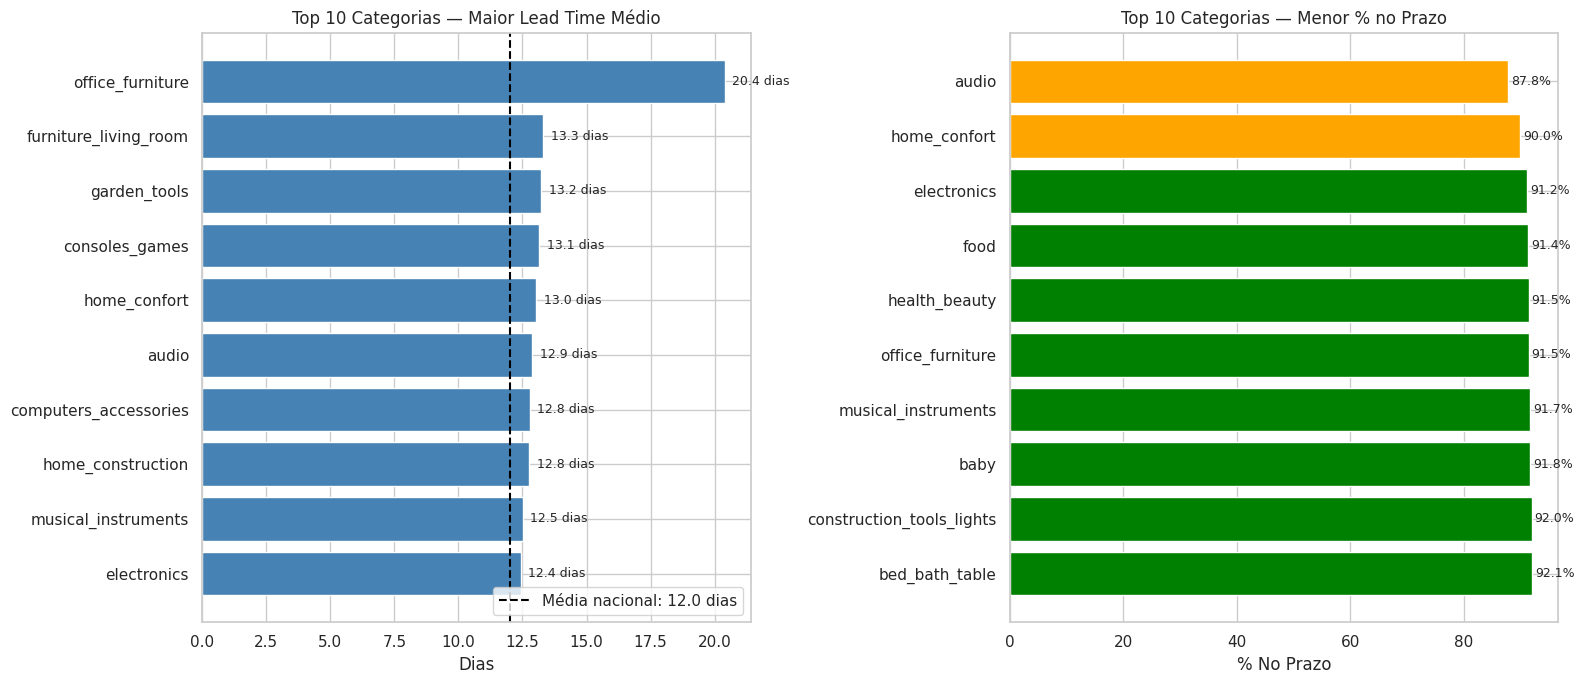

TOP 5 CATEGORIAS MAIS LENTAS (maior lead time médio)
  office_furniture: 20.4 dias | 91.5% no prazo | 1668 pedidos
  furniture_living_room: 13.3 dias | 92.3% no prazo | 495 pedidos
  garden_tools: 13.2 dias | 92.6% no prazo | 4268 pedidos
  consoles_games: 13.1 dias | 93.3% no prazo | 1089 pedidos
  home_confort: 13.0 dias | 90.0% no prazo | 429 pedidos

TOP 5 CATEGORIAS MAIS RÁPIDAS (menor lead time médio)
  food: 9.1 dias | 91.4% no prazo | 499 pedidos
  construction_tools_lights: 9.2 dias | 92.0% no prazo | 301 pedidos
  drinks: 10.0 dias | 94.7% no prazo | 361 pedidos
  luggage_accessories: 10.2 dias | 95.0% no prazo | 1077 pedidos
  construction_tools_construction: 10.3 dias | 92.1% no prazo | 916 pedidos


In [9]:
# ============================================================
# LEAD TIME POR CATEGORIA DE PRODUTO
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------
# a) Merges sucessivos: df_lead -> df_items -> df_products -> df_translate
#    Todos com how="left" para preservar todos os pedidos de df_lead
# --------------------------------------------------------------
df_cat = df_lead.merge(
    df_items[["order_id", "product_id"]], on="order_id", how="left"
)

df_cat = df_cat.merge(
    df_products[["product_id", "product_category_name"]], on="product_id", how="left"
)

df_cat = df_cat.merge(
    df_translate[["product_category_name", "product_category_name_english"]],
    on="product_category_name",
    how="left",
)

# --------------------------------------------------------------
# b) Agrupa por categoria (inglês), mantendo apenas categorias com >= 300 pedidos
# --------------------------------------------------------------
df_categoria = df_cat.groupby("product_category_name_english").agg(
    lead_medio=("lead_time_real", "mean"),
    total_pedidos=("lead_time_real", "count"),
    pct_no_prazo=("status_entrega", lambda x: (x == "No Prazo").sum() / len(x) * 100),
).reset_index()

df_categoria = df_categoria[df_categoria["total_pedidos"] >= 300]

# Média nacional de referência (sobre os pedidos com categoria identificada)
media_nacional_lead = df_cat["lead_time_real"].mean()

# --------------------------------------------------------------
# c) Figura 1x2 com os dois rankings
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ------------------------------------------------------------
# Subplot esquerdo: Top 10 categorias por maior lead_medio
#   Ordenado: mais lento no topo
# ------------------------------------------------------------
top10_lead = df_categoria.sort_values("lead_medio", ascending=False).head(10)
# Inverte para plotagem (mais lento no topo do gráfico horizontal)
plot_lead = top10_lead.sort_values("lead_medio", ascending=True)

ax = axes[0]
barras = ax.barh(plot_lead["product_category_name_english"], plot_lead["lead_medio"], color="steelblue")

ax.axvline(media_nacional_lead, color="black", linestyle="--", linewidth=1.5,
           label=f"Média nacional: {media_nacional_lead:.1f} dias")

# Valor numérico no final de cada barra
for barra, valor in zip(barras, plot_lead["lead_medio"]):
    ax.text(
        valor + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f} dias",
        va="center",
        fontsize=9,
    )

ax.set_title("Top 10 Categorias — Maior Lead Time Médio")
ax.set_xlabel("Dias")
ax.legend(loc="lower right")

# ------------------------------------------------------------
# Subplot direito: Top 10 categorias por menor pct_no_prazo (piores)
#   Cor por faixa: vermelho < 85%, laranja 85-90%, verde >= 90%
# ------------------------------------------------------------
top10_pct = df_categoria.sort_values("pct_no_prazo", ascending=True).head(10)
# Inverte para o pior (menor %) ficar no topo do gráfico
plot_pct = top10_pct.sort_values("pct_no_prazo", ascending=False)

def cor_pct(p):
    if p < 85:
        return "red"
    elif p < 90:
        return "orange"
    else:
        return "green"

cores_pct = [cor_pct(v) for v in plot_pct["pct_no_prazo"]]

ax = axes[1]
barras2 = ax.barh(plot_pct["product_category_name_english"], plot_pct["pct_no_prazo"], color=cores_pct)

for barra, valor in zip(barras2, plot_pct["pct_no_prazo"]):
    ax.text(
        valor + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}%",
        va="center",
        fontsize=9,
    )

ax.set_title("Top 10 Categorias — Menor % no Prazo")
ax.set_xlabel("% No Prazo")

plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# d) Tabela com top 5 mais lentas e top 5 mais rápidas
# --------------------------------------------------------------
print("=" * 65)
print("TOP 5 CATEGORIAS MAIS LENTAS (maior lead time médio)")
print("=" * 65)
top5_lentas = df_categoria.sort_values("lead_medio", ascending=False).head(5)
for _, row in top5_lentas.iterrows():
    print(
        f"  {row['product_category_name_english']}: {row['lead_medio']:.1f} dias "
        f"| {row['pct_no_prazo']:.1f}% no prazo | {int(row['total_pedidos'])} pedidos"
    )

print("\n" + "=" * 65)
print("TOP 5 CATEGORIAS MAIS RÁPIDAS (menor lead time médio)")
print("=" * 65)
top5_rapidas = df_categoria.sort_values("lead_medio", ascending=True).head(5)
for _, row in top5_rapidas.iterrows():
    print(
        f"  {row['product_category_name_english']}: {row['lead_medio']:.1f} dias "
        f"| {row['pct_no_prazo']:.1f}% no prazo | {int(row['total_pedidos'])} pedidos"
    )

print("=" * 65)

## Correlação: Tempo de Entrega vs Avaliação

### (a) O que é correlação de Pearson?

A **correlação de Pearson** é uma medida estatística que quantifica a força e a direção da relação **linear** entre duas variáveis numéricas. Varia de -1 a +1:

- **+1**: correlação positiva perfeita (quando uma sobe, a outra sobe na mesma proporção)
- **-1**: correlação negativa perfeita (quando uma sobe, a outra desce na mesma proporção)
- **0**: nenhuma relação linear detectável

Valores próximos de 0 indicam relação fraca; valores acima de ~0.3 ou abaixo de ~-0.3 já costumam ser considerados moderados em dados de comportamento humano/negócio (que são naturalmente ruidosos).

### (b) Hipótese testada

Nossa hipótese é: **entregas atrasadas (ou com lead time mais alto) tendem a correlacionar com notas de avaliação (review_score) piores**. Isto é, esperamos uma correlação **negativa**: quanto maior o atraso, menor a nota dada pelo cliente.

### (c) Correlação ≠ Causalidade

É fundamental destacar que encontrar uma correlação **não prova que uma variável causa a outra**. Mesmo que exista correlação negativa forte entre atraso e nota, isso não comprova isoladamente que o atraso *causou* a nota baixa — pode haver fatores de confusão (ex: produto chegou danificado, atendimento ruim, expectativa do cliente, categoria do produto) que afetam ambas as variáveis simultaneamente.

A correlação nos dá evidência de que **algo relevante está acontecendo** entre tempo de entrega e satisfação, mas conclusões causais exigiriam desenhos experimentais ou controles estatísticos adicionais (ex: regressão controlando por outras variáveis).

In [10]:
# ============================================================
# CORRELAÇÃO: TEMPO DE ENTREGA VS AVALIAÇÃO
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

# --------------------------------------------------------------
# a) Merge de df_lead com df_reviews por order_id (inner join)
# --------------------------------------------------------------
df_corr = df_lead.merge(df_reviews[["order_id", "review_score"]], on="order_id", how="inner")

# --------------------------------------------------------------
# b) Remove linhas onde review_score é nulo
# --------------------------------------------------------------
df_corr = df_corr.dropna(subset=["review_score"])

total_pedidos = len(df_corr)

# --------------------------------------------------------------
# c) Correlação de Pearson entre lead_time_real/diferenca_prazo e review_score
#    Usamos scipy.stats.pearsonr() para obter também o p-value
# --------------------------------------------------------------
corr_lead, pvalue_lead = stats.pearsonr(df_corr["lead_time_real"], df_corr["review_score"])
corr_diff, pvalue_diff = stats.pearsonr(df_corr["diferenca_prazo"], df_corr["review_score"])

# --------------------------------------------------------------
# d) Cria faixas de lead time com pd.cut()
# --------------------------------------------------------------
bins = [0, 7, 14, 21, 30, 999]
labels = ["0-7 dias", "8-14 dias", "15-21 dias", "22-30 dias", "> 30 dias"]

df_corr["faixa_lead_time"] = pd.cut(
    df_corr["lead_time_real"], bins=bins, labels=labels, include_lowest=True
)

# --------------------------------------------------------------
# e) Nota média e mediana por faixa de lead time
# --------------------------------------------------------------
df_faixa = df_corr.groupby("faixa_lead_time", observed=True).agg(
    nota_media=("review_score", "mean"),
    nota_mediana=("review_score", "median"),
    total_pedidos=("review_score", "count"),
).reset_index()

# Reordena conforme a ordem natural das faixas
df_faixa["faixa_lead_time"] = pd.Categorical(df_faixa["faixa_lead_time"], categories=labels, ordered=True)
df_faixa = df_faixa.sort_values("faixa_lead_time")

# --------------------------------------------------------------
# f) Nota média para "No Prazo" vs "Atrasado"
# --------------------------------------------------------------
nota_no_prazo = df_corr.loc[df_corr["status_entrega"] == "No Prazo", "review_score"].mean()
nota_atrasado = df_corr.loc[df_corr["status_entrega"] == "Atrasado", "review_score"].mean()

# --------------------------------------------------------------
# g) Relatório formatado
# --------------------------------------------------------------
print("=" * 65)
print("RELATÓRIO — CORRELAÇÃO TEMPO DE ENTREGA VS AVALIAÇÃO")
print("=" * 65)
print(f"Total de pedidos no merge (com review_score válido): {total_pedidos}")
print("-" * 65)
print("Correlação de Pearson:")
print(f"  lead_time_real  vs review_score: r = {corr_lead:.3f}  (p-value = {pvalue_lead:.4f})")
print(f"  diferenca_prazo vs review_score: r = {corr_diff:.3f}  (p-value = {pvalue_diff:.4f})")
print("-" * 65)
print("Nota média e mediana por faixa de lead time:")
print(f"  {'Faixa':<15}{'Nota Média':>12}{'Nota Mediana':>15}{'Pedidos':>12}")
for _, row in df_faixa.iterrows():
    print(
        f"  {str(row['faixa_lead_time']):<15}"
        f"{row['nota_media']:>12.1f}"
        f"{row['nota_mediana']:>15.1f}"
        f"{int(row['total_pedidos']):>12}"
    )
print("-" * 65)
print("Nota média — No Prazo vs Atrasado:")
print(f"  No Prazo:  {nota_no_prazo:.1f}")
print(f"  Atrasado:  {nota_atrasado:.1f}")
print("=" * 65)

RELATÓRIO — CORRELAÇÃO TEMPO DE ENTREGA VS AVALIAÇÃO
Total de pedidos no merge (com review_score válido): 96353
-----------------------------------------------------------------
Correlação de Pearson:
  lead_time_real  vs review_score: r = -0.334  (p-value = 0.0000)
  diferenca_prazo vs review_score: r = -0.267  (p-value = 0.0000)
-----------------------------------------------------------------
Nota média e mediana por faixa de lead time:
  Faixa            Nota Média   Nota Mediana     Pedidos
  0-7 dias                4.4            5.0       33683
  8-14 dias               4.3            5.0       36395
  15-21 dias              4.1            5.0       15381
  22-30 dias              3.5            4.0        6863
  > 30 dias               2.2            1.0        4031
-----------------------------------------------------------------
Nota média — No Prazo vs Atrasado:
  No Prazo:  4.3
  Atrasado:  2.5


## Visualizações da Correlação

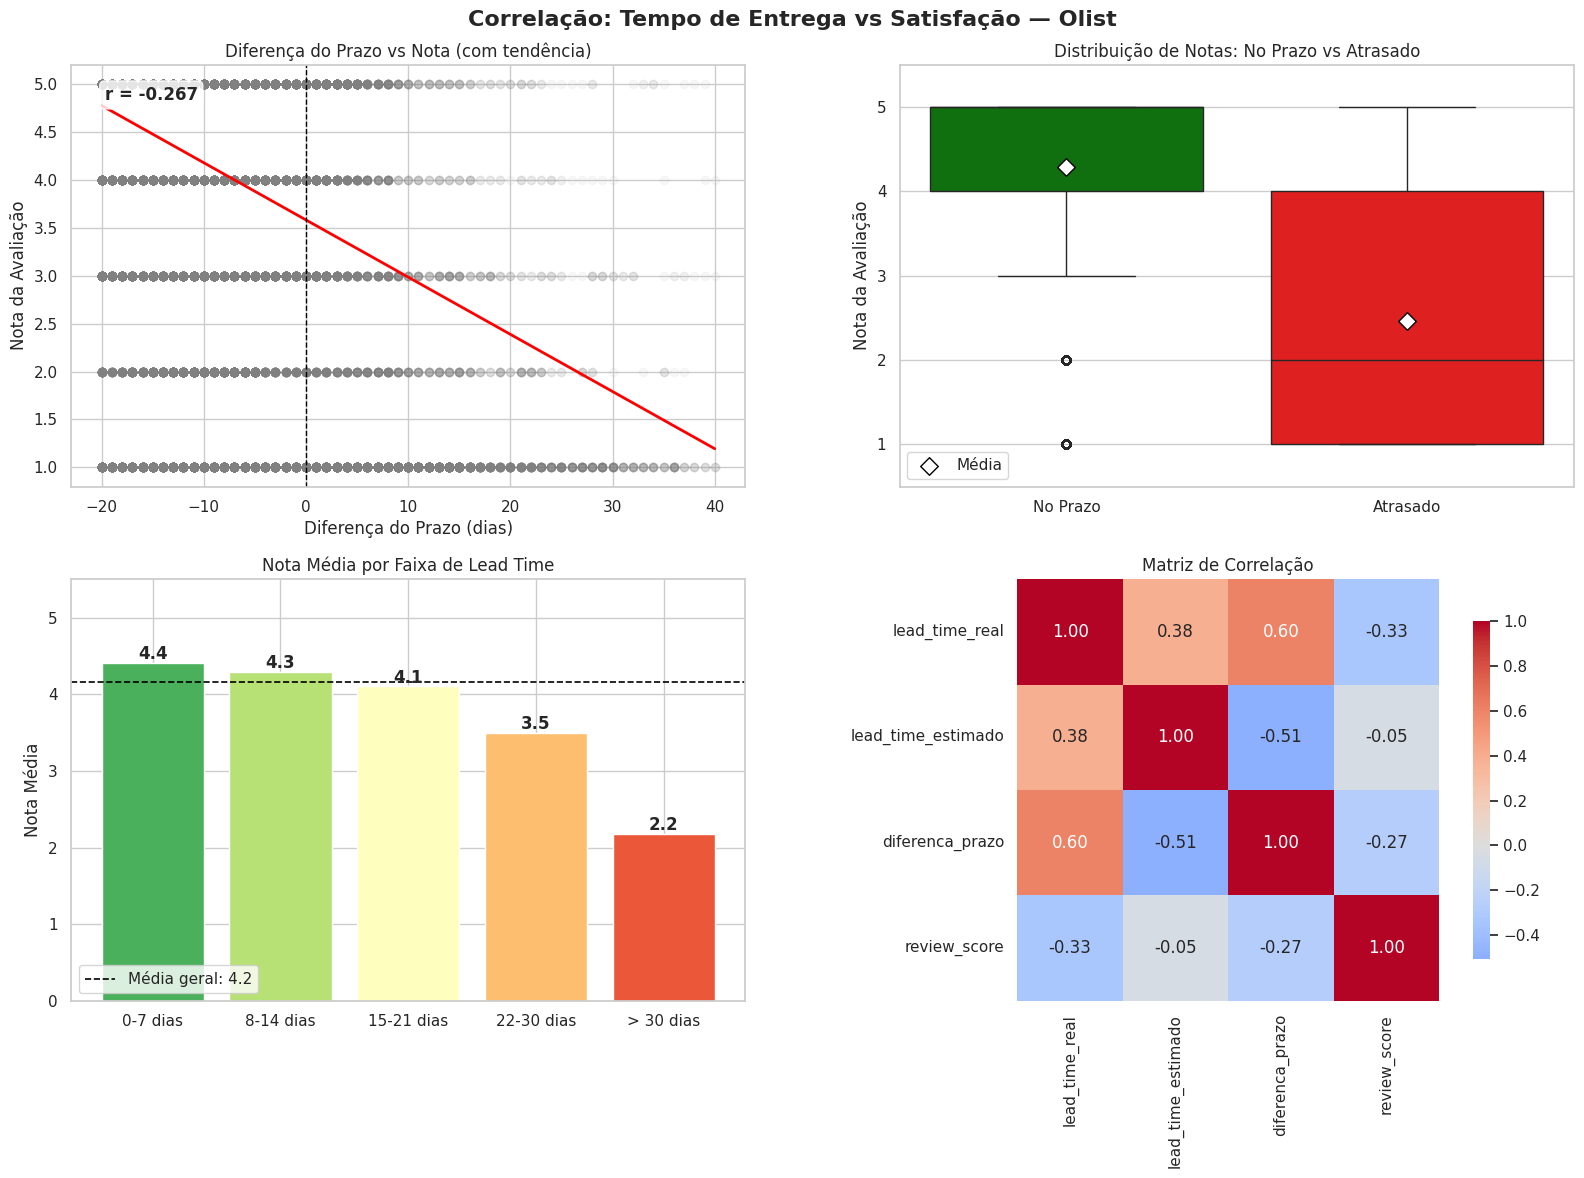

In [13]:
# ============================================================
# VISUALIZAÇÕES DA CORRELAÇÃO — TEMPO DE ENTREGA VS SATISFAÇÃO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Detecta automaticamente o nome correto da coluna de faixa de lead time
col_faixa = "faixa_lead" if "faixa_lead" in df_corr.columns else "faixa_lead_time"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --------------------------------------------------------------
# [0,0] Scatter: diferenca_prazo vs review_score, com linha de tendência
# --------------------------------------------------------------
ax = axes[0, 0]

# Filtra para a faixa de interesse (-20 a +40 dias) para melhor visualização
mask = (df_corr["diferenca_prazo"] >= -20) & (df_corr["diferenca_prazo"] <= 40)
dados_scatter = df_corr.loc[mask]

ax.scatter(
    dados_scatter["diferenca_prazo"],
    dados_scatter["review_score"],
    alpha=0.05,
    color="gray",
)

# Linha de tendência linear (regressão grau 1) via np.polyfit / np.poly1d
coef = np.polyfit(dados_scatter["diferenca_prazo"], dados_scatter["review_score"], deg=1)
tendencia = np.poly1d(coef)
x_linha = np.linspace(dados_scatter["diferenca_prazo"].min(), dados_scatter["diferenca_prazo"].max(), 100)
ax.plot(x_linha, tendencia(x_linha), color="red", linewidth=2)

# Linha vertical em x=0 (divisão no prazo / atrasado)
ax.axvline(0, color="black", linestyle="--", linewidth=1)

# Calcula r de Pearson (sobre os dados completos, não só os filtrados para o gráfico)
r_pearson, _ = stats.pearsonr(df_corr["diferenca_prazo"], df_corr["review_score"])
ax.annotate(
    f"r = {r_pearson:.3f}",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    fontweight="bold",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

ax.set_title("Diferença do Prazo vs Nota (com tendência)")
ax.set_xlabel("Diferença do Prazo (dias)")
ax.set_ylabel("Nota da Avaliação")

# --------------------------------------------------------------
# [0,1] Boxplot: review_score por status_entrega
# --------------------------------------------------------------
ax = axes[0, 1]

paleta = {"No Prazo": "green", "Atrasado": "red"}
ordem = ["No Prazo", "Atrasado"]

sns.boxplot(
    data=df_corr,
    x="status_entrega",
    y="review_score",
    order=ordem,
    palette=paleta,
    ax=ax,
)

# Adiciona ponto de média como diamante dentro de cada caixa
medias = df_corr.groupby("status_entrega")["review_score"].mean()
for i, cat in enumerate(ordem):
    ax.scatter(
        i, medias[cat],
        marker="D", color="white", edgecolor="black",
        s=80, zorder=3, label="Média" if i == 0 else None,
    )

ax.set_title("Distribuição de Notas: No Prazo vs Atrasado")
ax.set_ylabel("Nota da Avaliação")
ax.set_xlabel("")
ax.set_ylim(0.5, 5.5)
ax.legend(loc="lower left")

# --------------------------------------------------------------
# [1,0] Barplot: nota média por faixa de lead time
#   Cor em degradê do verde (notas altas) ao vermelho (notas baixas)
# --------------------------------------------------------------
ax = axes[1, 0]

df_faixa_plot = df_corr.groupby(col_faixa, observed=True)["review_score"].mean().reset_index()
df_faixa_plot.columns = [col_faixa, "nota_media"]

# Garante a ordem natural das faixas
labels_ordem = ["0-7 dias", "8-14 dias", "15-21 dias", "22-30 dias", "> 30 dias"]
df_faixa_plot[col_faixa] = pd.Categorical(df_faixa_plot[col_faixa], categories=labels_ordem, ordered=True)
df_faixa_plot = df_faixa_plot.sort_values(col_faixa)

# Paleta verde -> vermelho (RdYlGn invertida: notas altas verde, baixas vermelho)
paleta_cores = sns.color_palette("RdYlGn", n_colors=5)[::-1]

barras = ax.bar(
    df_faixa_plot[col_faixa].astype(str),
    df_faixa_plot["nota_media"],
    color=paleta_cores,
)

# Valores numéricos acima de cada barra
for barra, valor in zip(barras, df_faixa_plot["nota_media"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.1f}",
        ha="center",
        fontweight="bold",
    )

# Linha horizontal na nota média geral
nota_media_geral = df_corr["review_score"].mean()
ax.axhline(nota_media_geral, color="black", linestyle="--", linewidth=1.2,
           label=f"Média geral: {nota_media_geral:.1f}")

ax.set_title("Nota Média por Faixa de Lead Time")
ax.set_ylabel("Nota Média")
ax.set_ylim(0, 5.5)
ax.legend(loc="lower left")

# --------------------------------------------------------------
# [1,1] Heatmap de correlação entre as variáveis numéricas
# --------------------------------------------------------------
ax = axes[1, 1]

matriz_corr = df_corr[
    ["lead_time_real", "lead_time_estimado", "diferenca_prazo", "review_score"]
].corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    square=True,
    cbar_kws={"shrink": 0.8},
)

ax.set_title("Matriz de Correlação")

# --------------------------------------------------------------
# Título geral e salvamento
# --------------------------------------------------------------
fig.suptitle("Correlação: Tempo de Entrega vs Satisfação — Olist", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("correlacao_entrega_nota.png", dpi=120, bbox_inches="tight")
plt.show()

# Análise de Lead Time e Satisfação de Clientes — Olist

**Para**: Diretor de Logística (Felipe Rodrigues) e CEO

**Data**: Outubro 2018 | **Preparado por**: [Seu Nome]

## Resumo Executivo

A Olist processou 96.470 pedidos entregues no período analisado, com um lead time médio real de 12,1 dias (mediana de 10,0 dias) — contra uma promessa média ao cliente de 23,4 dias. Em termos absolutos, isso parece positivo: 92,4% dos pedidos chegam dentro do prazo estimado. O problema, contudo, não está na média nacional, e sim nas disparidades escondidas por trás dela.

Os achados revelam três pontos críticos:

1.  **Disparidade Regional Severa**: O estado mais lento (AM, com 26,0 dias em média) entrega 3,1x mais lento que o mais rápido (SP, com 8,3 dias). Embora o AM tenha apenas 145 pedidos, AL (24,0 dias, 397 pedidos, apenas 77,1% no prazo) é o caso mais crítico em volume e confiabilidade simultaneamente.
2.  **Degradação na Black Friday 2017**: Novembro de 2017 registrou uma degradação operacional clara: lead time subiu para 14,7 dias (vs. média de 12,0 nos demais meses) e o percentual no prazo caiu para 86,6% (vs. 93,4%), uma queda de quase 7 pontos percentuais. Isso ocorreu justamente no mês de maior visibilidade de marca, com volume 51% acima da média mensal (7.288 vs. 4.810 pedidos).
3.  **Correlação Negativa com Avaliação**: Existe uma correlação negativa moderada (r = -0,334) entre lead time e nota de avaliação — pedidos atrasados recebem, em média, 1,8 ponto menos que pedidos entregues no prazo (nota 2,5 vs. 4,3).

A urgência aqui é direta: a Black Friday 2018 está a poucas semanas de distância. Se o padrão de 2017 se repetir — sem nenhuma intervenção — a Olist deve esperar um pico de pedidos com atraso desproporcional concentrado em estados (AL, MA, SE, PA) e na categoria de móveis de escritório, com impacto direto e mensurável em reputação (notas) e, por extensão, em recompra. Este relatório traduz esses achados em 6 ações priorizadas e com prazo para mitigar o risco antes do evento.

## Diagnóstico Nacional de Lead Time

| Métrica                       | Valor          |
| :---------------------------- | :------------- |
| Total de pedidos analisados   | 96.470         |
| Pedidos descartados (datas nulas) | 8              |
| Lead time real — média        | 12,1 dias      |
| Lead time real — mediana      | 10,0 dias      |
| Lead time real — mínimo / máximo | 0 dias / 209 dias |
| Lead time estimado — média    | 23,4 dias      |
| % de entregas no prazo        | 92,4%          |
| % de entregas atrasadas       | 7,6%           |

**Interpretação**: A diferença entre o lead time real (12,1 dias) e o estimado (23,4 dias) mostra que a Olist opera com uma margem de segurança generosa nas promessas de prazo — em média, entrega quase 11 dias antes do prometido. Essa folga é positiva para a satisfação geral, mas mascara o problema real: os 7,6% de pedidos atrasados não estão distribuídos uniformemente — eles se concentram em regiões e categorias específicas, como detalhado a seguir, e é exatamente esse subconjunto que está destruindo valor de marca de forma desproporcional ao seu volume.

## Disparidades Regionais

**Top 5 estados mais lentos (maior lead time médio):**

| Estado | Lead Time Médio | % No Prazo | Pedidos |
| :----- | :-------------- | :--------- | :------ |
| AM     | 26,0 dias       | 96,6%      | 145     |
| AL     | 24,0 dias       | 77,1%      | 397     |
| PA     | 23,3 dias       | 87,8%      | 946     |
| MA     | 21,1 dias       | 81,2%      | 717     |
| SE     | 21,0 dias       | 84,8%      | 335     |

**Top 5 estados mais rápidos (menor lead time médio):**

| Estado | Lead Time Médio | % No Prazo | Pedidos |
| :----- | :-------------- | :--------- | :------ |
| SP     | 8,3 dias        | 94,7%      | 40.494  |
| PR     | 11,5 dias       | 95,4%      | 4.923   |
| MG     | 11,5 dias       | 94,8%      | 11.354  |
| DF     | 12,5 dias       | 93,4%      | 2.080   |
| SC     | 14,5 dias       | 90,8%      | 3.546   |

**Interpretação**: A disparidade entre AM (26,0 dias) e SP (8,3 dias) representa uma diferença de mais de 17 dias — um cliente no Amazonas espera, em média, 3,1x mais tempo que um cliente em São Paulo. No entanto, o caso mais preocupante operacionalmente é AL: combina alto lead time (24,0 dias) com a menor confiabilidade de prazo da lista (77,1%) e volume relevante (397 pedidos) — é o estado onde a promessa de entrega falha com mais frequência.

## Performance na Black Friday 2017

| Métrica             | Novembro/2017 (Black Friday) | Média dos demais meses |
| :------------------ | :--------------------------- | :--------------------- |
| Lead time médio     | 14,7 dias                    | 12,0 dias              |
| % no prazo          | 86,6%                        | 93,4%                  |
| Volume de pedidos   | 7.288                        | 4.810,1 (média mensal) |

**Interpretação**: Novembro de 2017 teve um volume 51% acima da média mensal, e essa sobrecarga se traduziu diretamente em degradação de serviço: o lead time subiu 22,5% e o percentual no prazo caiu quase 7 pontos percentuais. Esse padrão é um sinal claro de que a capacidade operacional da Olist não escalou proporcionalmente ao pico de demanda — um risco que se repete, e provavelmente se intensifica, na Black Friday 2018, dado o crescimento natural da base de clientes ano a ano.

## Análise por Categoria

**Top 5 categorias mais lentas (maior lead time médio):**

| Categoria                        | Lead Time Médio | % No Prazo | Pedidos |
| :------------------------------- | :-------------- | :--------- | :------ |
| office_furniture (móveis de escritório) | 20,4 dias       | 91,5%      | 1.668   |
| furniture_living_room (móveis de sala) | 13,3 dias       | 92,3%      | 495     |
| garden_tools (ferramentas de jardim)   | 13,2 dias       | 92,6%      | 4.268   |
| consoles_games (consoles e games)   | 13,1 dias       | 93,3%      | 1.089   |
| home_confort (conforto para o lar)   | 13,0 dias       | 90,0%      | 429     |

A categoria móveis de escritório lidera isoladamente o ranking de lentidão, com 20,4 dias em média — 8,3 dias acima da média nacional, um salto bem maior que o das demais categorias do top 5. Esse padrão é consistente com produtos de maior volume/peso, que exigem logística diferenciada e estão sujeitos a maior risco de avaria — merece atenção dedicada, especialmente se houver demanda elevada por home office na Black Friday.

## Impacto na Satisfação — Correlação com Reviews

A correlação de Pearson entre lead_time_real e review_score foi de r = -0,334 (e entre diferenca_prazo e review_score, r = -0,267), ambas estatisticamente significativas (p < 0,0001). Em linguagem simples: isso confirma que existe uma relação real e consistente — quanto mais tempo o pedido demora para chegar, menor a nota que o cliente dá. Não é um padrão fraco ou casual: é um dos sinais mais fortes e confiáveis de toda a análise.

**Nota Média por Status de Entrega:**

| Status    | Nota Média |
| :-------- | :--------- |
| No Prazo  | 4,3        |
| Atrasado  | 2,5        |

A diferença de 1,8 ponto entre pedidos no prazo e atrasados é o dado mais acionável de toda a análise — na prática, equivale a transformar um cliente satisfeito (nota 4-5) em um cliente insatisfeito (nota 2-3) apenas pelo atraso.

**Nota Média e Mediana por Faixa de Lead Time:**

| Faixa de Lead Time | Nota Média | Nota Mediana | Pedidos   |
| :----------------- | :--------- | :----------- | :-------- |
| 0-7 dias           | 4,4        | 5,0          | 33.683    |
| 8-14 dias          | 4,3        | 5,0          | 36.395    |
| 15-21 dias         | 4,1        | 5,0          | 15.381    |
| 22-30 dias         | 3,5        | 4,0          | 6.863     |
| > 30 dias          | 2,2        | 1,0          | 4.031     |

A queda de nota é progressiva e consistente: cada faixa adicional de tempo reduz a satisfação de forma previsível. O salto mais brusco ocorre acima de 30 dias, onde a nota mediana cai para 1,0 — ou seja, mais da metade desses 4.031 pedidos recebe a pior avaliação possível.

## Recomendações para o Black Friday 2018

| Ação                                                                                                                                                                                | Responsável                      | Prazo                  |
| :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :------------------------------- | :--------------------- |
| 1. Reforçar capacidade logística em AL, MA, SE e PA (parcerias com transportadoras regionais ou hubs intermediários) — priorizar AL pela combinação de alto volume relativo e baixa confiabilidade (77,1% no prazo) | Diretoria de Logística (Felipe Rodrigues) | 30 dias antes da BF    |
| 2. Criar plano de contingência de volume para novembro/2018, simulando pico de +51% sobre a média mensal (referência: 2017)                                                              | Planejamento Operacional         | 45 dias antes da BF    |
| 3. Revisar SLA de transportadoras para a categoria "office_furniture", priorizando frete dedicado para itens de maior porte                                                          | Compras/Supply Chain             | 30 dias antes da BF    |
| 4. Comunicação proativa ao cliente quando o pedido entrar em risco de atraso (e-mail/SMS automático com nova estimativa), com foco nos pedidos que historicamente passam de 22 dias  | Produto/CX                       | 20 dias antes da BF    |
| 5. Monitoramento em tempo real do % no prazo durante a BF, com alerta automático se cair abaixo de 90% (referência de queda de 2017: de 93,4% para 86,6%)                          | Dados/Operações                  | Início imediato (pré-BF) |
| 6. Programa de mitigação pós-atraso: cupom ou crédito automático para pedidos que ultrapassarem 22 dias, já que essa é a faixa onde a nota despenca de 4,1 para 3,5/2,2                 | CX/Marketing                     | 15 dias antes da BF    |

## Alertas e Riscos se Nada for Feito

*   **Risco reputacional concentrado**: Sem intervenção, a Black Friday 2018 deve repetir (ou agravar) a queda de ~7 pontos percentuais no prazo observada em 2017 (93,4% → 86,6%), impactando diretamente milhares de avaliações em um único mês de alta visibilidade.
*   **Efeito multiplicador em AL**: O estado já opera com apenas 77,1% no prazo em condições normais; um pico de demanda sem reforço logístico pode empurrar esse número para níveis ainda mais críticos.
*   **Erosão de LTV**: A queda de 1,8 ponto na nota média de pedidos atrasados — e de até 2,2 pontos acima de 30 dias — está diretamente associada a menor probabilidade de recompra; cada Black Friday mal executada gera não apenas reviews negativos, mas perda de receita futura.
*   **Categoria de alto risco sem plano definido**: "office_furniture", a categoria mais lenta da base (20,4 dias), tende a ter demanda elevada em novembro por conta de promoções de home office, agravando o problema se não houver SLA dedicado.
*   **Janela de ação se encurtando**: As recomendações acima dependem de lead time próprio de implementação (contratos com transportadoras, ajustes de sistema); adiar decisões além de 30 dias antes da Black Friday reduz drasticamente a capacidade de mitigação real.